# Aramark–Avendra Spend Analysis (EDA)
**CS 562 — Big Data Algorithms | Rutgers University**

## Objective
Explore the Aramark–Avendra dataset to identify spending patterns across customers, industries, locations, and product categories.

- Understand spending distribution
- Identify key drivers of spend
- Explore geographic and business differences
- Generate insights for future modeling

---
⚠️ **Run cells in order from top to bottom. Do not skip any cells.**

## Step 1: Authenticate with Google Cloud
Run this cell first. It will open a popup — sign in with your **@scarletmail.rutgers.edu** account.

In [1]:
from google.colab import auth
auth.authenticate_user()
print('✅ Authentication complete!')

✅ Authentication complete!


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

print(f'✅ pandas  {pd.__version__}')
print(f'✅ numpy   {np.__version__}')

✅ pandas  2.2.2
✅ numpy   2.0.2


## Step 3: Load Data

The file is **~8.5 GB**. We read it in chunks of 100,000 rows at a time so we never run out of memory.

⏱️ **This will take 10–20 minutes. Do not interrupt it.**

In [3]:
GCS_PATH   = 'gs://cs-562-aramark-project/Andrew_Meszaros_SRF_2026-04-01-0936.csv'
CHUNK_SIZE = 100_000
SPEND_COL  = 'Spend Random Factor'

chunks = []
total  = 0

print('Starting chunked read...')
for i, chunk in enumerate(pd.read_csv(GCS_PATH, chunksize=CHUNK_SIZE, dtype={'Zip': str})):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 10 == 0:
        print(f'  ...loaded {total:,} rows so far')

df = pd.concat(chunks, ignore_index=True)
print(f'\n✅ Data loaded! Shape: {df.shape}')
display(df.head())

Starting chunked read...
  ...loaded 1,000,000 rows so far
  ...loaded 2,000,000 rows so far
  ...loaded 3,000,000 rows so far
  ...loaded 4,000,000 rows so far
  ...loaded 5,000,000 rows so far
  ...loaded 6,000,000 rows so far
  ...loaded 7,000,000 rows so far
  ...loaded 8,000,000 rows so far
  ...loaded 9,000,000 rows so far
  ...loaded 10,000,000 rows so far
  ...loaded 11,000,000 rows so far
  ...loaded 12,000,000 rows so far
  ...loaded 13,000,000 rows so far
  ...loaded 14,000,000 rows so far
  ...loaded 15,000,000 rows so far
  ...loaded 16,000,000 rows so far
  ...loaded 17,000,000 rows so far
  ...loaded 18,000,000 rows so far
  ...loaded 19,000,000 rows so far
  ...loaded 20,000,000 rows so far
  ...loaded 21,000,000 rows so far
  ...loaded 22,000,000 rows so far
  ...loaded 23,000,000 rows so far
  ...loaded 24,000,000 rows so far
  ...loaded 25,000,000 rows so far
  ...loaded 26,000,000 rows so far
  ...loaded 27,000,000 rows so far
  ...loaded 28,000,000 rows so far
  ..

,Year Name,Year Month,Business Entity Type,Country,Customer Market Segment Id,Client ID,Customer Id,Customer Brand Id,Customer Brand Parent Id,City,...,Ecommerce Status,Distributor ID,Distributor Group,Manufacturer ID,Category ID,Category Level 1,Category Level 2,Category Level 3,Category Level 4,Spend Random Factor
0,2025,202510,GPO,US,MS-100025,A0083918,C-CL0463-1,INDE,A0064145,PINEHURST,...,NaN,100114.0,TURF MANAGEMENT,M-105168,71.34.20.51.00,GOLF EQUIPMENT AND SUPPLIES,SPECIALIZED VEHICLES,SPECIALIZED VEHICLES,TURF UTILITY VEHICLES,1.237354e+06
1,2025,202512,GPO,US,MS-100026,A0091384,C-A0098350-1,WSVC,A0091384,LAHAINA,...,NaN,100079.0,ENGINEERING CLEANING SERVICES,M-100479,64.17.00.00.00,CHEMICALS AND CLEANING,CLEANING AND JANITORIAL SERVICES,NaN,NaN,6.002968e+05
2,2025,202507,MANAGED SERVICES,US,MS-100007,CF0000100,C-000010698-1,MS-100007,NaN,GUILFORD,...,ACTIVE,105067.0,ENGINEERING OTHER,NaN,65.41.00.00.00,MAINTENANCE AND ENGINEERING,M&E SERVICES,NaN,NaN,5.862804e+05
3,2025,202505,GPO,US,MS-100026,A0091384,C-A0098350-1,WSVC,A0091384,LAHAINA,...,NaN,100079.0,ENGINEERING CLEANING SERVICES,M-100479,64.17.00.00.00,CHEMICALS AND CLEANING,CLEANING AND JANITORIAL SERVICES,NaN,NaN,5.756939e+05
4,2025,202510,GPO,US,MS-100026,A0091384,C-A0098350-1,WSVC,A0091384,LAHAINA,...,NaN,100079.0,ENGINEERING CLEANING SERVICES,M-100479,64.17.00.00.00,CHEMICALS AND CLEANING,CLEANING AND JANITORIAL SERVICES,NaN,NaN,5.753405e+05


## Step 4: Dataset Overview

In [4]:
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  - {col}')

Rows:    42,967,459
Columns: 23

Column names:
  - Year Name
  - Year Month
  - Business Entity Type
  - Country
  - Customer Market Segment Id
  - Client ID
  - Customer Id
  - Customer Brand Id
  - Customer Brand Parent Id
  - City
  - State
  - Zip
  - Number of Rooms
  - Ecommerce Status
  - Distributor ID
  - Distributor Group
  - Manufacturer ID
  - Category ID
  - Category Level 1
  - Category Level 2
  - Category Level 3
  - Category Level 4
  - Spend Random Factor


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42967459 entries, 0 to 42967458
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Year Name                   int64  
 1   Year Month                  int64  
 2   Business Entity Type        object 
 3   Country                     object 
 4   Customer Market Segment Id  object 
 5   Client ID                   object 
 6   Customer Id                 object 
 7   Customer Brand Id           object 
 8   Customer Brand Parent Id    object 
 9   City                        object 
 10  State                       object 
 11  Zip                         object 
 12  Number of Rooms             int64  
 13  Ecommerce Status            object 
 14  Distributor ID              float64
 15  Distributor Group           object 
 16  Manufacturer ID             object 
 17  Category ID                 object 
 18  Category Level 1            object 
 19  Category Level 2   

In [7]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

,Year Name,Year Month,Number of Rooms,Distributor ID,Spend Random Factor
count,"42,967,459.00","42,967,459.00","42,967,459.00","42,930,033.00","42,967,459.00"
mean,"2,025.00","202,506.52",103.20,"100,074.20",142.97
std,0.00,3.43,168.19,407.97,"1,100.42"
min,"2,025.00","202,501.00",0.00,"100,000.00","-135,013.73"
25%,"2,025.00","202,504.00",0.00,"100,001.00",17.72
50%,"2,025.00","202,507.00",51.00,"100,002.00",37.03
75%,"2,025.00","202,510.00",143.00,"100,024.00",93.08
max,"2,025.00","202,512.00","4,899.00","106,267.00","1,237,354.17"


## Step 5: Data Cleaning

In [8]:
print('Missing values per column:')
display(df.isnull().sum().sort_values(ascending=False))

Missing values per column:


,0
Ecommerce Status,32269283
Customer Brand Parent Id,11107827
Manufacturer ID,5433073
Customer Brand Id,2273626
Category Level 4,835973
Category Level 3,285314
Category Level 2,100085
Distributor Group,62320
Distributor ID,37426
Client ID,3049


In [9]:
before = len(df)
df = df.dropna(subset=[SPEND_COL])
df[SPEND_COL] = pd.to_numeric(df[SPEND_COL], errors='coerce')
df = df.dropna(subset=[SPEND_COL])
after = len(df)

print(f'Rows before cleaning: {before:,}')
print(f'Rows after  cleaning: {after:,}')
print(f'Rows dropped:         {before - after:,}')

Rows before cleaning: 42,967,459
Rows after  cleaning: 42,967,459
Rows dropped:         0


## Step 6: Exploratory Analysis

### 6.1 Spend by Category Level 1
Which top-level product categories drive the most total spend?

In [10]:
category_spend = df.groupby('Category Level 1')[SPEND_COL].sum().sort_values(ascending=False)
display(category_spend.reset_index().rename(columns={SPEND_COL: 'Total Spend (USD)'}))

,Category Level 1,Total Spend (USD)
0,FOOD,"3,695,921,092.88"
1,BEVERAGE,"637,775,122.61"
2,DISPOSABLES,"415,461,473.11"
3,MAINTENANCE AND ENGINEERING,"381,648,750.97"
4,CHEMICALS AND CLEANING,"346,193,921.75"
5,ROOM AND SPA,"233,263,025.51"
6,FOOD SERVICE EQUIPMENT AND SUPPLIES,"157,071,153.45"
7,CLOTHING AND FOOTWEAR,"81,922,318.33"
8,FURNITURE FIXTURES AND EQUIPMENT,"67,229,044.22"
9,GOLF EQUIPMENT AND SUPPLIES,"65,972,437.70"


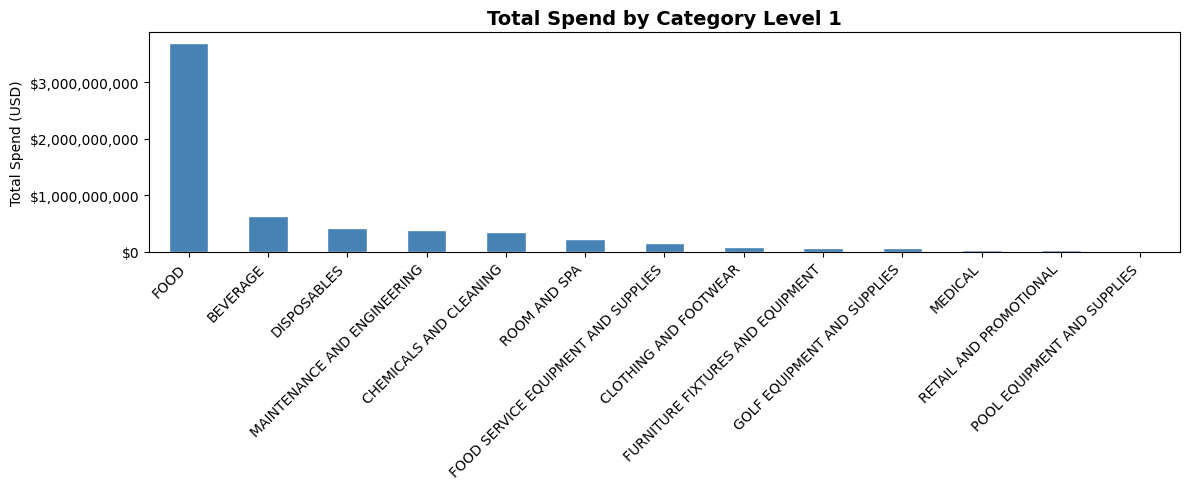

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
category_spend.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Spend by Category Level 1', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Spend (USD)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

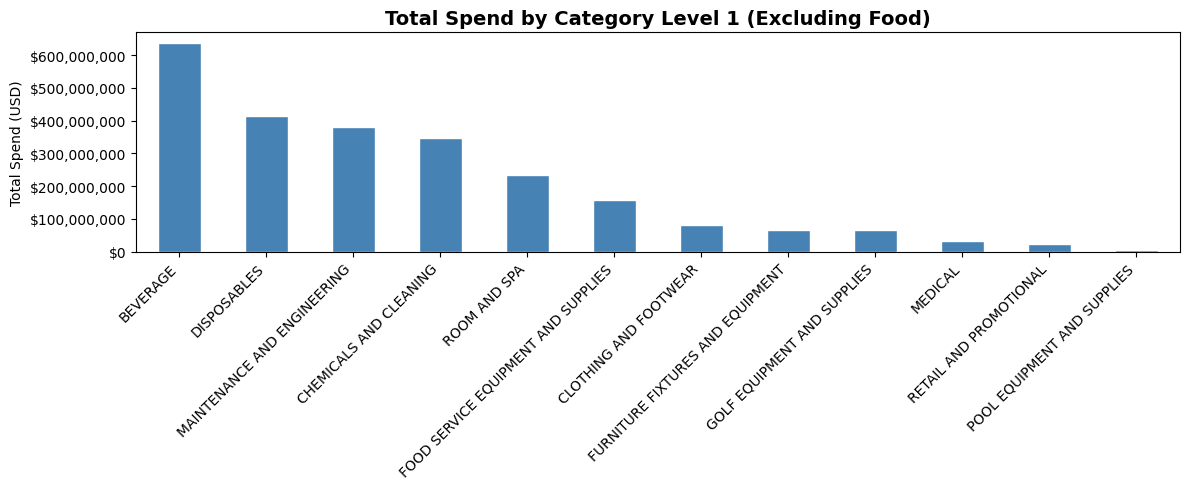

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
category_spend.drop('FOOD').plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Spend by Category Level 1 (Excluding Food)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Spend (USD)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Spend by State
Geographic distribution of spend across US states.

In [13]:
state_spend = df.groupby('State')[SPEND_COL].sum().sort_values(ascending=False)
display(state_spend.head(10).reset_index().rename(columns={SPEND_COL: 'Total Spend (USD)'}))

,State,Total Spend (USD)
0,CA,"869,499,953.40"
1,TX,"615,573,242.78"
2,FL,"583,675,600.44"
3,PA,"286,890,457.36"
4,IL,"264,431,570.69"
5,NY,"230,677,420.47"
6,NC,"210,926,482.65"
7,VA,"209,252,124.02"
8,GA,"187,000,555.66"
9,OH,"166,533,976.41"


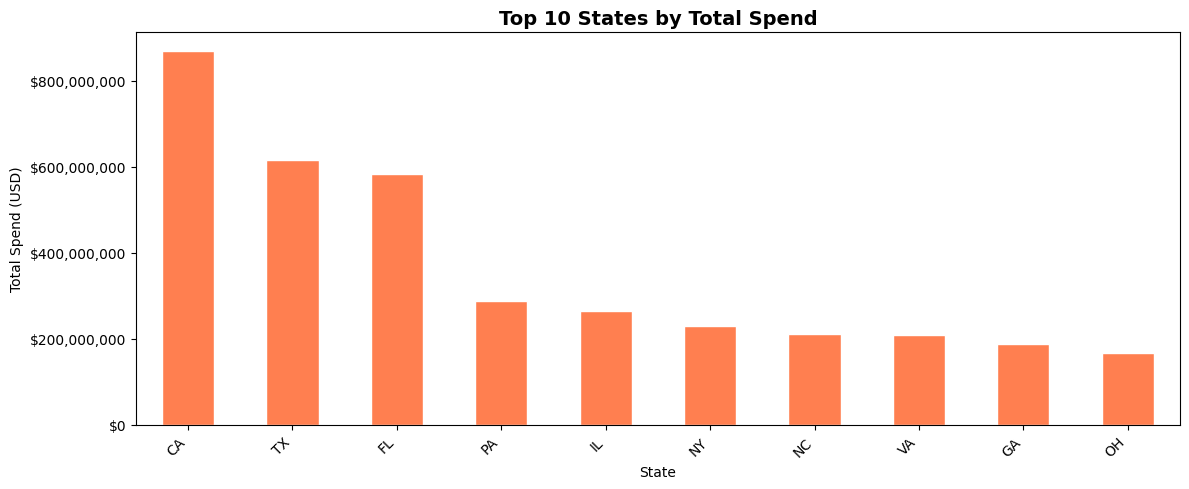

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
state_spend.head(10).plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 10 States by Total Spend', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Spend (USD)')
ax.set_xlabel('State')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.3 Spend by Business Entity Type
Average spend per transaction across different business types.

In [15]:
business_spend = df.groupby('Business Entity Type')[SPEND_COL].mean().sort_values(ascending=False)
display(business_spend.reset_index().rename(columns={SPEND_COL: 'Avg Spend (USD)'}))

,Business Entity Type,Avg Spend (USD)
0,MANAGED SERVICES,248.90
1,GPO,116.20


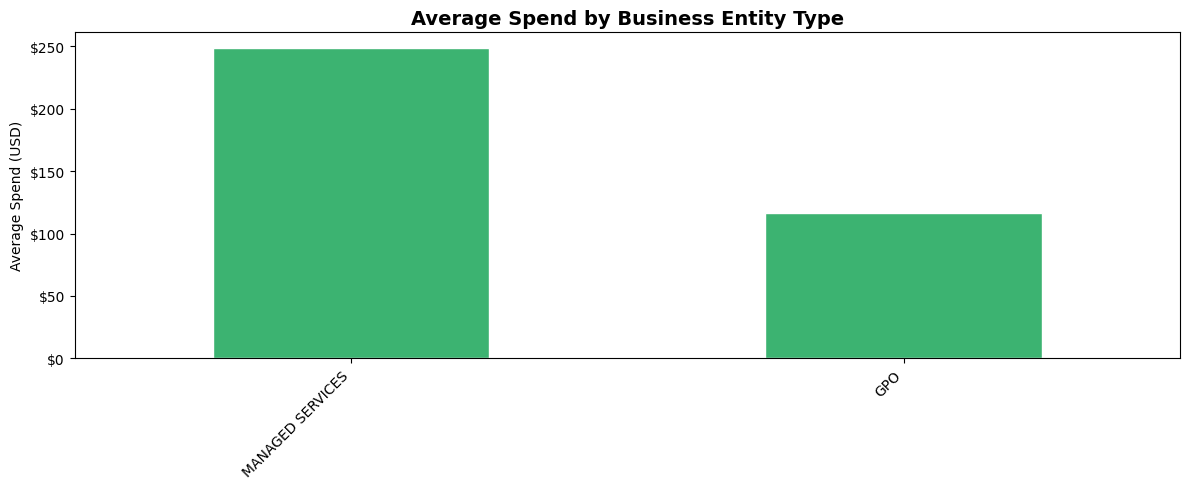

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
business_spend.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Average Spend by Business Entity Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Spend (USD)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Spend by City
Top 10 cities by total spend.

In [17]:
city_spend = df.groupby('City')[SPEND_COL].sum().sort_values(ascending=False)
display(city_spend.head(10).reset_index().rename(columns={SPEND_COL: 'Total Spend (USD)'}))

,City,Total Spend (USD)
0,HOUSTON,"150,888,893.24"
1,ORLANDO,"109,040,025.29"
2,CHICAGO,"107,095,007.32"
3,PHILADELPHIA,"83,504,998.57"
4,NEW YORK,"82,476,764.99"
5,WASHINGTON,"63,652,404.60"
6,TAMPA,"60,460,798.38"
7,NASHVILLE,"59,755,950.40"
8,DALLAS,"57,886,829.87"
9,BOSTON,"53,813,767.13"


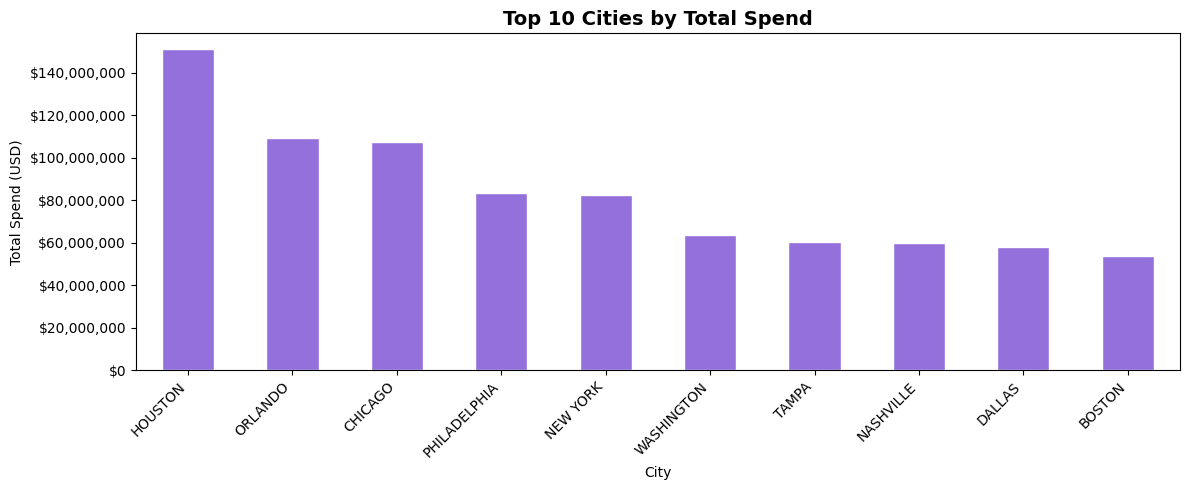

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
city_spend.head(10).plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Top 10 Cities by Total Spend', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Spend (USD)')
ax.set_xlabel('City')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.5 Ecommerce vs Non-Ecommerce Spending
Does ecommerce adoption correlate with higher average spend?

In [19]:
ecom_spend = df.groupby('Ecommerce Status')[SPEND_COL].mean().sort_values(ascending=False)
display(ecom_spend.reset_index().rename(columns={SPEND_COL: 'Avg Spend (USD)'}))

,Ecommerce Status,Avg Spend (USD)
0,ACTIVE,119.57
1,INACTIVE,115.68
2,PENDING,114.70
3,ACTIVATED,72.83


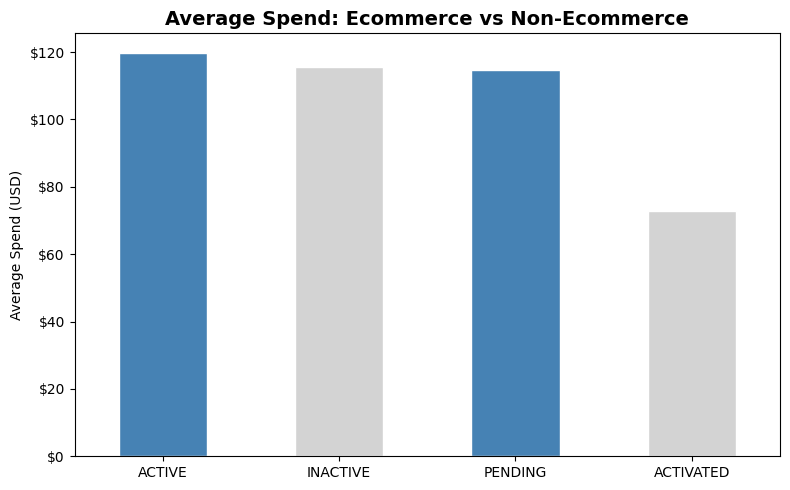

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ecom_spend.plot(kind='bar', ax=ax, color=['steelblue', 'lightgray'], edgecolor='white')
ax.set_title('Average Spend: Ecommerce vs Non-Ecommerce', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Spend (USD)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.6 Spend Distribution
What does the overall distribution of spend look like?

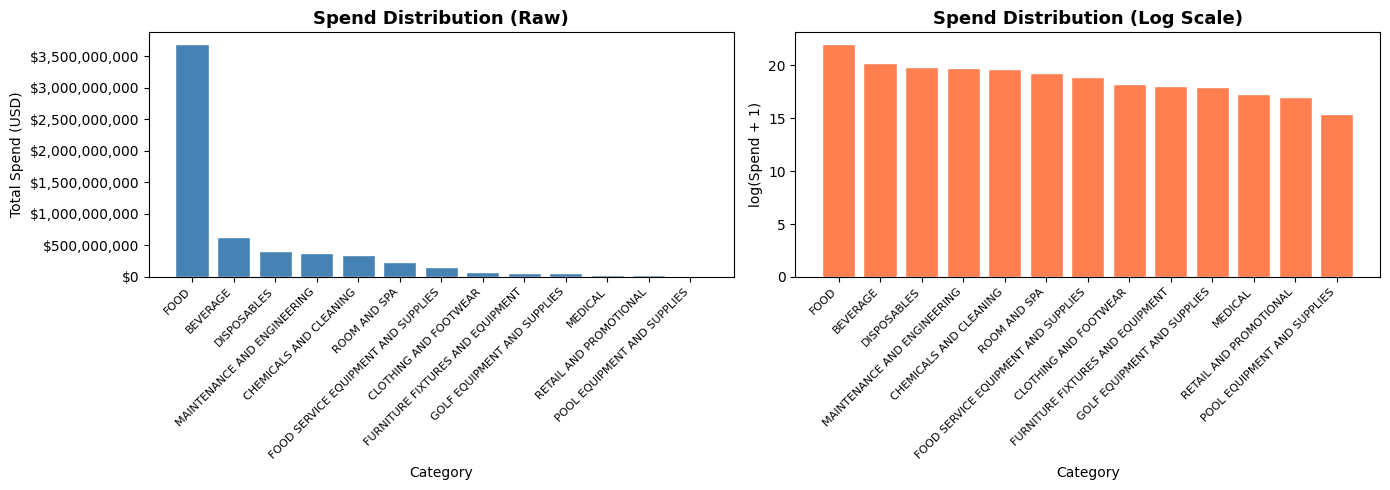

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution using category spend values
spend_sample = category_spend.values

axes[0].bar(range(len(category_spend)), spend_sample, color='steelblue', edgecolor='white')
axes[0].set_title('Spend Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend (USD)')
axes[0].set_xticks(range(len(category_spend)))
axes[0].set_xticklabels(category_spend.index, rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log distribution
positive_spend = spend_sample[spend_sample > 0]
axes[1].bar(range(len(positive_spend)), np.log1p(positive_spend), color='coral', edgecolor='white')
axes[1].set_title('Spend Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('log(Spend + 1)')
axes[1].set_xticks(range(len(positive_spend)))
axes[1].set_xticklabels(category_spend.index[:len(positive_spend)], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

### 6.7 Top Category Level 2 within each Category Level 1
Drilling one level deeper into the category hierarchy.

In [24]:
cat2_spend = (
    df.groupby(['Category Level 1', 'Category Level 2'])[SPEND_COL]
    .sum()
    .reset_index()
    .sort_values(SPEND_COL, ascending=False)
)

# Top 3 sub-categories per Category Level 1
top_cat2 = cat2_spend.groupby('Category Level 1').head(3)
display(top_cat2.rename(columns={SPEND_COL: 'Total Spend (USD)'}))

,Category Level 1,Category Level 2,Total Spend (USD)
19,FOOD,GROCERY,"672,986,256.50"
24,FOOD,PRODUCE,"637,828,690.30"
20,FOOD,MEAT,"565,574,424.56"
14,DISPOSABLES,DISPOSABLES,"415,452,446.91"
10,CHEMICALS AND CLEANING,CLEANING SUPPLIES,"216,400,707.10"
47,MAINTENANCE AND ENGINEERING,M&E SERVICES,"161,428,235.79"
2,BEVERAGE,COFFEE,"137,754,050.93"
5,BEVERAGE,"NON-CARB, NON-DAIRY","137,457,001.26"
4,BEVERAGE,JUICE,"131,839,616.90"
67,ROOM AND SPA,TEXTILES AND BEDDING,"130,958,476.05"


## Step 7: Key Insights

Fill this in after running the analysis above:

- **Top category:** _[fill in after running]_
- **Top state:** _[fill in after running]_
- **Top city:** _[fill in after running]_
- **Business type with highest avg spend:** _[fill in after running]_
- **Ecommerce impact:** _[fill in after running]_

These insights provide the foundation for next steps: clustering, spend prediction, and association rule mining.

## Step 8: Save Results

In [25]:
os.makedirs('results', exist_ok=True)

category_spend.to_csv('results/category_spend.csv')
state_spend.to_csv('results/state_spend.csv')
city_spend.to_csv('results/city_spend.csv')
business_spend.to_csv('results/business_spend.csv')
ecom_spend.to_csv('results/ecom_spend.csv')

print('✅ Results saved to /results folder!')
print('   To download: click the folder icon on the left sidebar in Colab')

✅ Results saved to /results folder!
   To download: click the folder icon on the left sidebar in Colab


## Next Steps

Based on this EDA, the project will move toward:

1. **Customer Segmentation** — K-Means or DBSCAN clustering on spend patterns by location + category
2. **Spend Prediction** — Regression / ML models using business type, location, category, ecommerce status
3. **Association Rule Mining** — Frequent itemsets across categories per customer (MMDS Chapter 6)

Final direction will be selected based on data patterns observed in this EDA.